In [1]:

from sunpy.net import Fido, attrs as a
from stixpy.net.client import STIXClient 

# Defining the time range for the GOES data
start_time = "2024-05-14T00:00:00"
end_time = "2024-05-15T00:00:00"


sci_query = Fido.search(a.Time(start_time, end_time), 
                        a.Instrument.stix,
                        a.stix.DataType.sci)
print(" Science data of STIX Files:", sci_query)

 Science data of STIX Files: Results from 1 Provider:

32 Results from the STIXClient:

       Start Time               End Time        Instrument Level DataType  DataProduct  Ver Request ID
----------------------- ----------------------- ---------- ----- -------- ------------- --- ----------
2024-05-14 00:27:08.000 2024-05-14 00:29:42.000       STIX    L1      SCI  sci-xray-cpd V02 2405140232
2024-05-14 00:34:14.000 2024-05-14 00:37:48.000       STIX    L1      SCI  sci-xray-cpd V02 2405141740
2024-05-14 00:54:12.000 2024-05-14 03:12:52.000       STIX    L1      SCI  sci-xray-cpd V02 2405144786
2024-05-14 00:54:36.000 2024-05-14 01:00:28.000       STIX    L1      SCI  sci-xray-cpd V02 2405141518
2024-05-14 01:09:35.000 2024-05-14 01:11:01.000       STIX    L1      SCI  sci-xray-cpd V02 2405146104
2024-05-14 01:40:09.000 2024-05-14 01:46:00.000       STIX    L1      SCI  sci-xray-cpd V02 2405148255
2024-05-14 01:58:27.000 2024-05-14 02:18:12.000       STIX    L1      SCI  sci-xray-cpd 

In [2]:
# Downloading the data
sci_files = Fido.fetch(sci_query)

Files Downloaded:   0%|          | 0/32 [00:00<?, ?file/s]

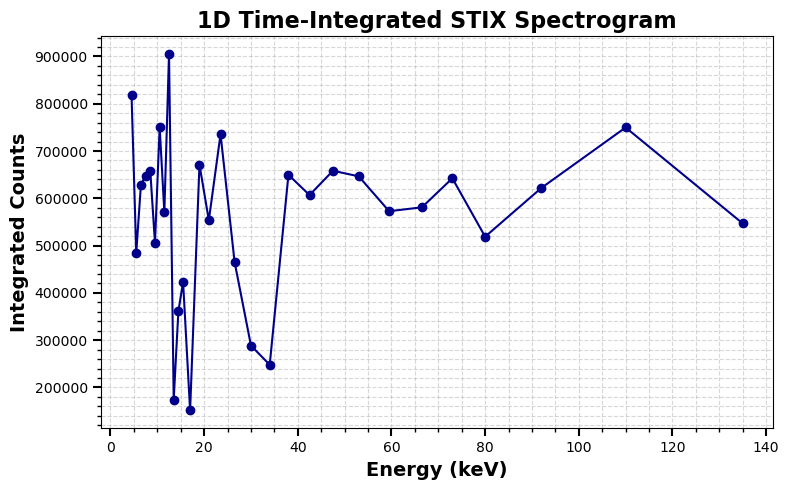

In [19]:
# Event-1

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
import matplotlib.dates as mdates  # For UTC time formatting



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[6])  # Select the file

spec     # call to check the file details


# Define time range
start_time = Time('2024-05-14T02:02:45')
end_time = Time('2024-05-14T02:05:15')

# Extract time indices from spec
times = Time(spec.data['time'])
time_mask = (times >= start_time) & (times <= end_time)
time_indices = np.where(time_mask)[0]

#print(time_mask)
#print(time_indices)


# Extract energy bounds
e_low = spec.energies['e_low']
e_high = spec.energies['e_high']
energy_bin_centers = 0.5 * (e_low + e_high)
#print(energy_bin_centers.shape)


# Extract and sum counts: shape (time, energy, detector, pixel)

counts = spec.data['counts']  # [t, e, d, p]
#print(counts.shape)

time_filtered_counts = counts[time_indices, :, :, :]
#print(time_filtered_counts.shape)  

summed_counts = time_filtered_counts.sum(axis=(0, 2, 3))
#print(summed_counts.shape)

summed_counts = summed_counts[:31]  # Trim to match energy_bin_centers
#print(summed_counts.shape)


# Plot the 1D spectrogram
plt.figure(figsize=(8, 5))
plt.plot(energy_bin_centers, summed_counts.value, marker='o', linestyle='-', color='darkblue')
plt.xlabel("Energy (keV)", fontsize=14, fontweight='bold')
plt.ylabel("Integrated Counts", fontsize=14, fontweight='bold')
plt.title("1D Time-Integrated STIX Spectrogram", fontsize=16, fontweight='bold')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', direction='out', length=6, width=1.5)
plt.tick_params(axis='both', which='minor', direction='out', length=3, width=1)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8241/2232865504.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


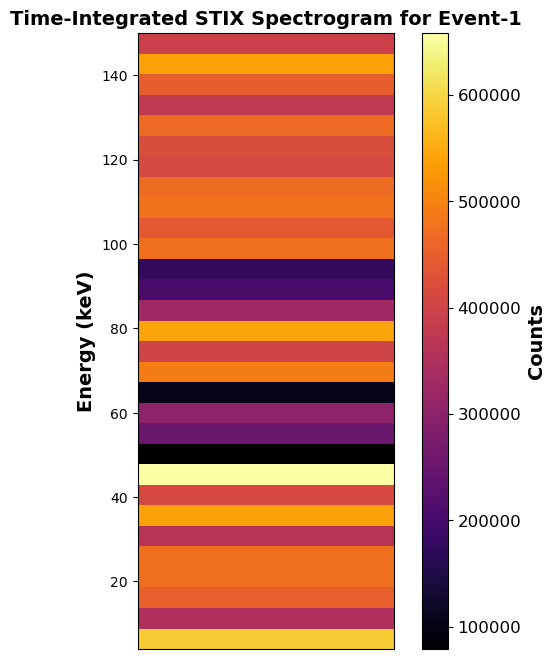

In [3]:
# Event-1

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from stixpy.product import Product
from matplotlib import gridspec



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[6])  # Select the file

spec     # call to check the file details


# Load STIX spectrogram file
spec = Product(sci_files[6])  # Make sure sci_files is already defined

# Define time range
start_time = Time('2024-05-14T02:02:45')
#end_time = Time('2024-05-14T02:05:15')
end_time = Time('2024-05-14T02:03:45')   # Filtered


# Time indices selection
times = Time(spec.data['time'])
time_indices = np.where((times >= start_time) & (times <= end_time))[0]

# Get full energy bin edges (32 total)
e_low_full = spec.energies['e_low'].to(u.keV).value  # 31 values
e_high_full = spec.energies['e_high'].to(u.keV).value  # 31 values

# Get count data (shape: [time, energy=32, det, pix])
counts = spec.data['counts']

# Sum counts over time, detectors, and pixels
counts_summed = counts[time_indices, :, :, :].sum(axis=(0, 2, 3))  # shape: (32,)

# Drop the last bin to match the 31 energy bins (e.g., remove overflow or invalid bin)
counts_summed = counts_summed[:31].value  # drop the last bin and strip units

# Now apply valid energy mask (in case of NaNs)
valid_energy_mask = np.isfinite(e_low_full) & np.isfinite(e_high_full)
e_low = e_low_full[valid_energy_mask]
e_high = e_high_full[valid_energy_mask]
counts_summed = counts_summed[valid_energy_mask]

# Make it 2D for imshow
spectro_1d = counts_summed[:, np.newaxis]  # shape: (n_energy_bins, 1)

# Create a figure with custom GridSpec
fig = plt.figure(figsize=(4, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[10, 1], wspace=0.2)

# Plot the spectrogram
ax = fig.add_subplot(gs[0])
img = ax.imshow(spectro_1d, aspect='auto', origin='lower', cmap='inferno',
                extent=[0, 1, e_low[0], e_high[-1]])

# Colorbar in a separate subplot (taller)
cax = fig.add_subplot(gs[1])
cbar = plt.colorbar(img, cax=cax)
cbar.set_label("Counts", fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

ax.set_xticks([])  # Remove x-axis
ax.set_ylabel("Energy (keV)", fontsize=14, fontweight='bold')
ax.set_title("Time-Integrated STIX Spectrogram for Event-1", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True]
(236, 17, 8, 17)


/tmp/ipykernel_24308/4148705853.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


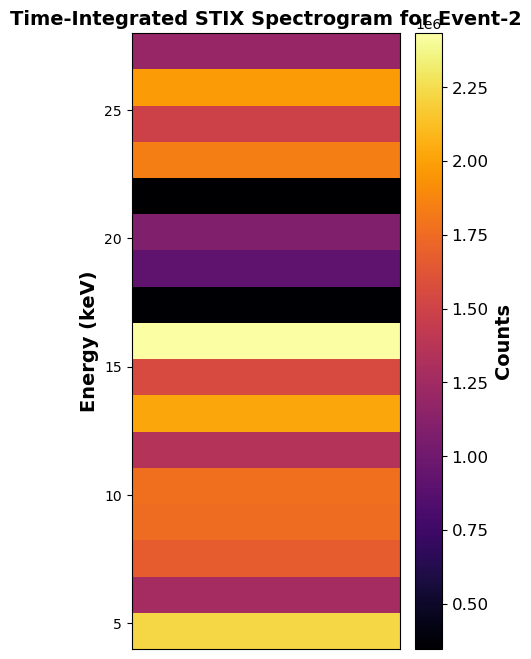

In [79]:
# Event-2

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from stixpy.product import Product
from matplotlib import gridspec



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)

spec = Product(sci_files[6])  # Select the file

spec     # call to check the file details

# Load STIX spectrogram file
spec = Product(sci_files[12])

# Define time range
start_time = Time('2024-05-14T12:42:30')
end_time = Time('2024-05-14T12:49:30')

# Time indices selection
times = Time(spec.data['time'])
time_indices = np.where((times >= start_time) & (times <= end_time))[0]

# Energy bounds (31 values: bin edges)
e_low_full = spec.energies['e_low'].to(u.keV).value
e_high_full = spec.energies['e_high'].to(u.keV).value


# Create valid energy mask
valid_energy_mask = np.isfinite(e_low_full) & np.isfinite(e_high_full)
print(valid_energy_mask)


# Apply mask to energy bounds
e_low = e_low_full[valid_energy_mask]
e_high = e_high_full[valid_energy_mask]

# Drop overflow bin
counts = spec.data['counts'][:, :17, :, :]  # shape: (time, 32, det, pix)



# Now apply valid energy mask safely 
counts = counts[:, valid_energy_mask, :, :]  # shape: (time, valid_energies, det, pix)
print(counts.shape)


# Sum over time, detectors, and pixels
counts_summed = counts[time_indices, :, :, :].sum(axis=(0, 2, 3)).value

# Reshape for imshow
spectro_1d = counts_summed[:, np.newaxis]

# Plotting
fig = plt.figure(figsize=(4, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[10, 1], wspace=0.1)

ax = fig.add_subplot(gs[0])
img = ax.imshow(spectro_1d, aspect='auto', origin='lower', cmap='inferno',
                extent=[0, 1, e_low[0], e_high[-1]])

# Colorbar
cax = fig.add_subplot(gs[1])
cbar = plt.colorbar(img, cax=cax)
cbar.set_label("Counts", fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Labels
ax.set_xticks([])
ax.set_ylabel("Energy (keV)", fontsize=14, fontweight='bold')
ax.set_title("Time-Integrated STIX Spectrogram for Event-2", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]
(126, 27, 8, 27)


/tmp/ipykernel_24308/1163727469.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


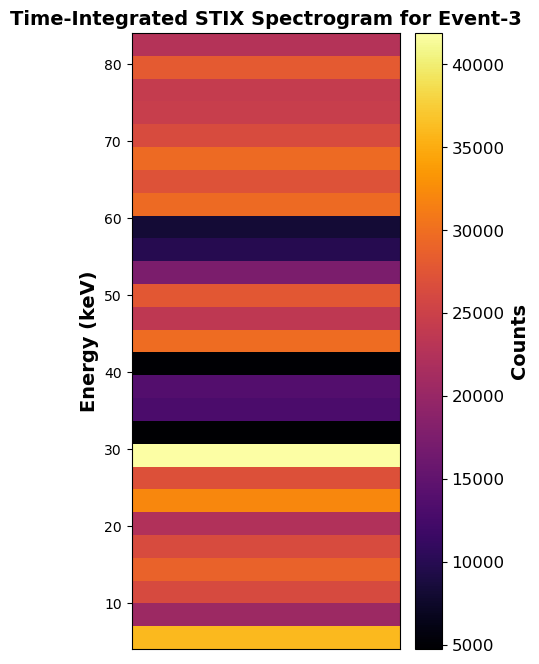

In [83]:
# Event-3

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from stixpy.product import Product
from matplotlib import gridspec



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)


# Load STIX spectrogram file
spec = Product(sci_files[16])
spec     # call to check the file details

# Define time range
start_time = Time('2024-05-14T15:18:00')
end_time = Time('2024-05-14T15:19:30')

# Time indices selection
times = Time(spec.data['time'])
time_indices = np.where((times >= start_time) & (times <= end_time))[0]

# Energy bounds (31 values: bin edges)
e_low_full = spec.energies['e_low'].to(u.keV).value
e_high_full = spec.energies['e_high'].to(u.keV).value


# Create valid energy mask
valid_energy_mask = np.isfinite(e_low_full) & np.isfinite(e_high_full)
print(valid_energy_mask)


# Apply mask to energy bounds
e_low = e_low_full[valid_energy_mask]
e_high = e_high_full[valid_energy_mask]

# Drop overflow bin
counts = spec.data['counts'][:, :27, :, :]  # shape: (time, 32, det, pix)



# Now apply valid energy mask safely 
counts = counts[:, valid_energy_mask, :, :]  # shape: (time, valid_energies, det, pix)
print(counts.shape)


# Sum over time, detectors, and pixels
counts_summed = counts[time_indices, :, :, :].sum(axis=(0, 2, 3)).value

# Reshape for imshow
spectro_1d = counts_summed[:, np.newaxis]

# Plotting
fig = plt.figure(figsize=(4, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[10, 1], wspace=0.1)

ax = fig.add_subplot(gs[0])
img = ax.imshow(spectro_1d, aspect='auto', origin='lower', cmap='inferno',
                extent=[0, 1, e_low[0], e_high[-1]])

# Colorbar
cax = fig.add_subplot(gs[1])
cbar = plt.colorbar(img, cax=cax)
cbar.set_label("Counts", fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Labels
ax.set_xticks([])
ax.set_ylabel("Energy (keV)", fontsize=14, fontweight='bold')
ax.set_title("Time-Integrated STIX Spectrogram for Event-3", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]
(473, 27, 8, 27)


/tmp/ipykernel_24308/3747252016.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


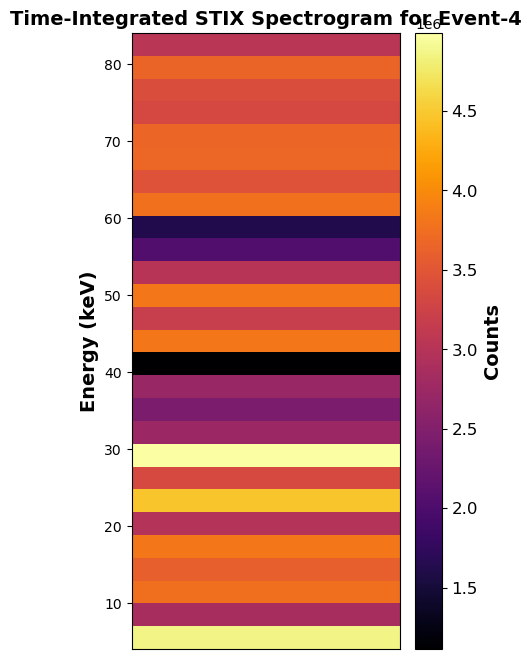

In [86]:
# Event-4

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from stixpy.product import Product
from matplotlib import gridspec



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)


# Load STIX spectrogram file
spec = Product(sci_files[19])
spec     # call to check the file details

# Define time range
start_time = Time('2024-05-14T16:43:30')
end_time = Time('2024-05-14T16:51:30')

# Time indices selection
times = Time(spec.data['time'])
time_indices = np.where((times >= start_time) & (times <= end_time))[0]

# Energy bounds (31 values: bin edges)
e_low_full = spec.energies['e_low'].to(u.keV).value
e_high_full = spec.energies['e_high'].to(u.keV).value


# Create valid energy mask
valid_energy_mask = np.isfinite(e_low_full) & np.isfinite(e_high_full)
print(valid_energy_mask)


# Apply mask to energy bounds
e_low = e_low_full[valid_energy_mask]
e_high = e_high_full[valid_energy_mask]

# Drop overflow bin
counts = spec.data['counts'][:, :27, :, :]  # shape: (time, 32, det, pix)



# Now apply valid energy mask safely 
counts = counts[:, valid_energy_mask, :, :]  # shape: (time, valid_energies, det, pix)
print(counts.shape)


# Sum over time, detectors, and pixels
counts_summed = counts[time_indices, :, :, :].sum(axis=(0, 2, 3)).value

# Reshape for imshow
spectro_1d = counts_summed[:, np.newaxis]

# Plotting
fig = plt.figure(figsize=(4, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[10, 1], wspace=0.1)

ax = fig.add_subplot(gs[0])
img = ax.imshow(spectro_1d, aspect='auto', origin='lower', cmap='inferno',
                extent=[0, 1, e_low[0], e_high[-1]])

# Colorbar
cax = fig.add_subplot(gs[1])
cbar = plt.colorbar(img, cax=cax)
cbar.set_label("Counts", fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Labels
ax.set_xticks([])
ax.set_ylabel("Energy (keV)", fontsize=14, fontweight='bold')
ax.set_title("Time-Integrated STIX Spectrogram for Event-4", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True False]
(482, 30, 8, 31)


/tmp/ipykernel_24308/2958387548.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


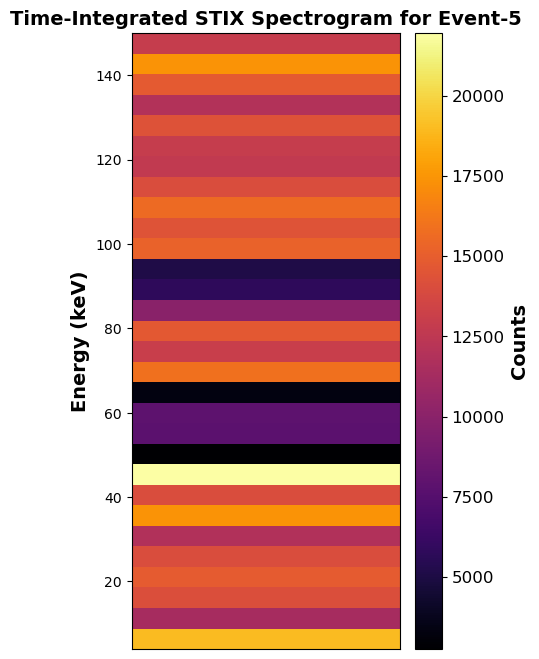

In [89]:
# Event-5

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.time import Time
from stixpy.product import Product
from matplotlib import gridspec



# Getting Compressed pixel data(cpd)

from stixpy.product import Product

sci_files = sorted(sci_files)


# Load STIX spectrogram file
spec = Product(sci_files[23])
spec     # call to check the file details

# Define time range
start_time = Time('2024-05-14T18:03:10')
end_time = Time('2024-05-14T18:04:00')

# Time indices selection
times = Time(spec.data['time'])
time_indices = np.where((times >= start_time) & (times <= end_time))[0]

# Energy bounds (31 values: bin edges)
e_low_full = spec.energies['e_low'].to(u.keV).value
e_high_full = spec.energies['e_high'].to(u.keV).value


# Create valid energy mask
valid_energy_mask = np.isfinite(e_low_full) & np.isfinite(e_high_full)
print(valid_energy_mask)


# Apply mask to energy bounds
e_low = e_low_full[valid_energy_mask]
e_high = e_high_full[valid_energy_mask]

# Drop overflow bin
counts = spec.data['counts'][:, :-1, :, :]  # shape: (time, 32, det, pix)



# Now apply valid energy mask safely 
counts = counts[:, valid_energy_mask, :, :]  # shape: (time, valid_energies, det, pix)
print(counts.shape)


# Sum over time, detectors, and pixels
counts_summed = counts[time_indices, :, :, :].sum(axis=(0, 2, 3)).value

# Reshape for imshow
spectro_1d = counts_summed[:, np.newaxis]

# Plotting
fig = plt.figure(figsize=(4, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[10, 1], wspace=0.1)

ax = fig.add_subplot(gs[0])
img = ax.imshow(spectro_1d, aspect='auto', origin='lower', cmap='inferno',
                extent=[0, 1, e_low[0], e_high[-1]])

# Colorbar
cax = fig.add_subplot(gs[1])
cbar = plt.colorbar(img, cax=cax)
cbar.set_label("Counts", fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# Labels
ax.set_xticks([])
ax.set_ylabel("Energy (keV)", fontsize=14, fontweight='bold')
ax.set_title("Time-Integrated STIX Spectrogram for Event-5", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()